# 고배당 전략: 유동성 30% + 배당상위 30% + 배당안정성 + 저 IVOL

전략 규칙
- 유니버스: 60일 평균 거래대금 기준 상위 30%
- 1차 필터: 배당수익률 상위 30%
- 2차 필터: 최근 3개 연간 구간에서 DPS 감소폭이 `MAX_YEARLY_DPS_DROP` 이하이고, 4개 시점의 DPS가 모두 양수인 종목만 통과
- 최종선정: `ivol`이 낮은 `TOP_N` 종목 동일가중
- 리밸런싱: 월말 선정, 다음 월 수익률 반영


## 셀 1. 환경 설정과 파라미터



In [24]:
# 셀 1. 라이브러리와 실행 파라미터를 설정합니다.

# Path는 입력/출력 파일의 절대 경로를 안전하게 다루기 위해 사용합니다.
from pathlib import Path

# numpy/pandas는 수치 계산과 패널 데이터 처리,
# matplotlib은 성과 시각화,
# display는 DataFrame을 보기 좋게 출력할 때 사용합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 노트북에서 차트를 일관된 스타일로 보기 위해 기본 스타일을 지정합니다.
plt.style.use("seaborn-v0_8")

# 전략 파일이 위치한 기준 폴더입니다.
BASE_DIR = Path("/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략")

# 가격, DPS, IVOL 입력 파일이 들어 있는 폴더입니다.
INPUT_DIR = BASE_DIR / "input"

# 거래대금 파일은 별도의 Robustness Test 폴더에 있어서 따로 경로를 잡습니다.
LIQUIDITY_PATH = BASE_DIR.parent / "Robustness Test" / "input" / "trading value 60.csv"

# 유동성 상위 몇 %를 유니버스로 볼지 정합니다.
LIQUIDITY_TOP_RATIO = 0.50

# 유동성 유니버스 안에서 배당수익률 상위 몇 %를 남길지 정합니다.
DIVIDEND_TOP_RATIO = 0.30

# 최종적으로 같은 비중으로 담을 종목 수입니다.
TOP_N = 10

# DPS 데이터는 공시/반영 시차를 고려해 15개월 뒤로 밀어서 사용합니다.
DPS_SHIFT_MONTHS = 15

# 연간 DPS 감소 허용 한도입니다.
# 예: 0.20이면 전년 대비 20%를 넘게 줄인 종목은 탈락합니다.
MAX_YEARLY_DPS_DROP = 0.20

# 백테스트 시작일입니다.
BACKTEST_START = "2010-12-31"

# 종료일을 제한하고 싶지 않으면 None을 둡니다.
BACKTEST_END = None

# 결과 CSV 파일명 앞에 붙는 공통 접두어입니다.
OUTPUT_PREFIX = "liquidity30_divtop30_dpsstable_ivol15_ew"


# CSV를 읽을 때 날짜 인덱스를 자동으로 파싱하도록 만든 헬퍼 함수입니다.
def load_csv(path: Path) -> pd.DataFrame:
    # 첫 번째 컬럼을 날짜 인덱스로 읽고, 메모리 경고를 줄이기 위해 low_memory=False를 사용합니다.
    return pd.read_csv(path, index_col=0, parse_dates=True, low_memory=False)


## 셀 2. 데이터 로딩과 월말 패널 생성


In [25]:
# 셀 2. 원천 데이터를 불러오고 월말 패널로 변환합니다.

# 원본 DPS, 배당반영 수정주가, IVOL, 거래대금 데이터를 읽습니다.
adj_dps_raw = load_csv(INPUT_DIR / "수정DPS.csv")
adj_close_raw = load_csv(INPUT_DIR / "배당반영수정주가.csv")
ivol_raw = load_csv(INPUT_DIR / "ivol_df_60.csv")
liquidity_raw = load_csv(LIQUIDITY_PATH)

# DPS는 월말 기준으로 맞춘 뒤, 실제 투자 시점에서 미래정보를 보지 않도록 15개월 시차를 둡니다.
adj_dps = (
    adj_dps_raw.resample("ME")
    .last()
    .shift(DPS_SHIFT_MONTHS)
    .apply(pd.to_numeric, errors="coerce")
)

# 가격은 월말 종가 기준으로 맞추고 숫자형으로 변환합니다.
adj_close = (
    adj_close_raw.resample("ME")
    .last()
    .apply(pd.to_numeric, errors="coerce")
)

# IVOL도 월말 기준으로 맞춰 같은 날짜축에서 비교할 수 있게 만듭니다.
ivol = (
    ivol_raw.resample("ME")
    .last()
    .apply(pd.to_numeric, errors="coerce")
)

# 거래대금 역시 월말 기준으로 정리해 유동성 랭킹에 사용합니다.
liquidity = (
    liquidity_raw.resample("ME")
    .last()
    .apply(pd.to_numeric, errors="coerce")
)

# 다음 달 보유 수익률 계산에 사용할 월수익률입니다.
monthly_ret = adj_close.pct_change(fill_method=None)

# 배당수익률 = 시차 반영 DPS / 현재 월말 주가입니다.
# 0으로 나누는 문제에서 생기는 무한대 값은 결측치로 바꿉니다.
div_yield = (adj_dps / adj_close).replace([np.inf, -np.inf], np.nan)

# 패널 크기를 출력해 데이터 정렬 상태를 빠르게 점검합니다.
print(f"DPS panel shape: {adj_dps.shape}")
print(f"Price panel shape: {adj_close.shape}")
print(f"IVOL panel shape: {ivol.shape}")
print(f"Liquidity panel shape: {liquidity.shape}")


DPS panel shape: (254, 3898)
Price panel shape: (219, 3933)
IVOL panel shape: (253, 3897)
Liquidity panel shape: (434, 3933)


## 셀 3. 배당안정성 필터 생성




In [26]:
# 셀 3. 최근 3년 기준 배당안정성 필터를 만듭니다.

# 현재 시점과 비교할 12개월, 24개월, 36개월 전 DPS를 준비합니다.
dps_lag12 = adj_dps.shift(12)
dps_lag24 = adj_dps.shift(24)
dps_lag36 = adj_dps.shift(36)

# 연간 DPS 변화율을 3개 구간으로 나눠 계산합니다.
# dps_yoy_1: 올해 vs 1년 전
# dps_yoy_2: 1년 전 vs 2년 전
# dps_yoy_3: 2년 전 vs 3년 전
dps_yoy_1 = (adj_dps / dps_lag12 - 1).replace([np.inf, -np.inf], np.nan)
dps_yoy_2 = (dps_lag12 / dps_lag24 - 1).replace([np.inf, -np.inf], np.nan)
dps_yoy_3 = (dps_lag24 / dps_lag36 - 1).replace([np.inf, -np.inf], np.nan)

# stable_dividend는 아래 두 조건을 동시에 만족하는 종목만 True로 표시합니다.
# 1) 최근 4개 연간 관측 시점의 DPS가 모두 양수일 것
# 2) 각 연간 감소율이 허용 한도(-MAX_YEARLY_DPS_DROP)보다 나쁘지 않을 것
stable_dividend = (
    adj_dps.gt(0)
    & dps_lag12.gt(0)
    & dps_lag24.gt(0)
    & dps_lag36.gt(0)
    & dps_yoy_1.ge(-MAX_YEARLY_DPS_DROP)
    & dps_yoy_2.ge(-MAX_YEARLY_DPS_DROP)
    & dps_yoy_3.ge(-MAX_YEARLY_DPS_DROP)
)

# 최근 시점에서 전체 종목 중 몇 %가 안정성 필터를 통과하는지 확인합니다.
print("최근 월말 기준 배당안정성 통과 비율")
display(stable_dividend.mean(axis=1).dropna().tail().rename("stable_ratio").to_frame())


최근 월말 기준 배당안정성 통과 비율


,stable_ratio
Date,
2025-10-31,0.170087
2025-11-30,0.170087
2025-12-31,0.170087
2026-01-31,0.170087
2026-02-28,0.170087


## 셀 4. 공통 인덱스 정리와 성과 함수


In [27]:
# 셀 4. 공통 날짜/종목을 정리하고 성과 계산 함수를 정의합니다.

# 모든 패널에서 동시에 존재하는 월말 날짜만 남깁니다.
common_index = (
    div_yield.index
    .intersection(monthly_ret.index)
    .intersection(ivol.index)
    .intersection(liquidity.index)
    .intersection(stable_dividend.index)
    .sort_values()
)

# 모든 패널에서 동시에 존재하는 종목만 남깁니다.
common_cols = (
    div_yield.columns
    .intersection(monthly_ret.columns)
    .intersection(ivol.columns)
    .intersection(liquidity.columns)
    .intersection(stable_dividend.columns)
)

# 사용자가 시작일을 지정했다면 해당 시점 이후 데이터만 사용합니다.
if BACKTEST_START is not None:
    common_index = common_index[common_index >= pd.Timestamp(BACKTEST_START)]

# 사용자가 종료일을 지정했다면 해당 시점 이전 데이터만 사용합니다.
if BACKTEST_END is not None:
    common_index = common_index[common_index <= pd.Timestamp(BACKTEST_END)]

# 최소한 한 번의 선정월과 한 번의 보유월은 있어야 백테스트가 가능합니다.
if len(common_index) < 2:
    raise ValueError("백테스트 구간이 너무 짧습니다. BACKTEST_START/BACKTEST_END를 확인하세요.")

# 정리된 공통 날짜/종목 기준으로 모든 패널을 다시 자릅니다.
div_yield = div_yield.loc[common_index, common_cols]
monthly_ret = monthly_ret.loc[common_index, common_cols]
ivol = ivol.loc[common_index, common_cols]
liquidity = liquidity.loc[common_index, common_cols]
stable_dividend = stable_dividend.loc[common_index, common_cols]

# 실제 백테스트에 사용되는 표본 범위를 확인합니다.
print(f"Backtest range: {common_index.min().date()} ~ {common_index.max().date()}")
print(f"Common stock count: {len(common_cols)}")


# 월별 수익률 시리즈를 받아 핵심 성과지표를 계산하는 함수입니다.
def compute_performance(returns: pd.Series, avg_names: float) -> pd.DataFrame:
    # 누적 NAV를 계산합니다.
    nav = (1 + returns).cumprod()

    # 월 데이터를 연환산하기 위한 총 연수입니다.
    years = len(returns) / 12

    # 연환산 변동성입니다.
    ann_vol = returns.std() * np.sqrt(12) if len(returns) > 1 else np.nan

    # 무위험수익률 0 가정의 단순 샤프 비율입니다.
    sharpe = (
        returns.mean() / returns.std() * np.sqrt(12)
        if len(returns) > 1 and returns.std() > 0
        else np.nan
    )

    # 최대낙폭 계산을 위해 NAV 기준 드로우다운을 만듭니다.
    drawdown = nav / nav.cummax() - 1

    # 요약 표를 DataFrame 한 줄 형태로 반환합니다.
    return pd.DataFrame(
        [
            {
                "start_date": returns.index.min().date().isoformat(),
                "end_date": returns.index.max().date().isoformat(),
                "n_months": int(len(returns)),
                "cagr": nav.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan,
                "annual_vol": ann_vol,
                "sharpe": sharpe,
                "mdd": drawdown.min(),
                "avg_monthly_return": returns.mean(),
                "hit_rate": (returns > 0).mean(),
                "avg_selected_names": avg_names,
            }
        ]
    )


Backtest range: 2010-12-31 ~ 2026-01-31
Common stock count: 3249


## 셀 5. 월별 종목선정과 백테스트 실행

유동성 필터, 배당 필터, 배당안정성 필터, `ivol` 필터를 순서대로 적용하고 다음 달 수익률을 계산합니다.


In [28]:
# 셀 5. 월별 리밸런싱 백테스트를 수행합니다.

# selection_dates는 종목을 고르는 날짜,
# holding_months는 실제로 수익률이 실현되는 다음 달입니다.
selection_dates = common_index[:-1]
holding_months = common_index[1:]

# 월별 수익률, 보유종목, 선정 통계 저장용 컨테이너입니다.
portfolio_returns = {}
portfolio_holdings = {}
selection_rows = []

# 매월 말 종목을 고르고, 다음 월 수익률을 기록합니다.
for selection_date, holding_month in zip(selection_dates, holding_months):
    # 현재 선정월의 단면 데이터입니다.
    dy_cs = div_yield.loc[selection_date].astype(float)
    ivol_cs = ivol.loc[selection_date].astype(float)
    liquidity_cs = liquidity.loc[selection_date].astype(float)
    stable_cs = stable_dividend.loc[selection_date].fillna(False)

    # 기본 유효성 조건입니다.
    # 배당수익률이 양수이고, ivol/거래대금이 존재하며, 거래대금이 0보다 커야 합니다.
    base_mask = (
        dy_cs.notna()
        & np.isfinite(dy_cs)
        & (dy_cs > 0)
        & ivol_cs.notna()
        & np.isfinite(ivol_cs)
        & liquidity_cs.notna()
        & np.isfinite(liquidity_cs)
        & (liquidity_cs > 0)
    )
    base_count = int(base_mask.sum())
    if base_count < TOP_N:
        continue

    # 1단계: 거래대금 상위 30% 유니버스를 만듭니다.
    liquidity_cutoff = liquidity_cs[base_mask].quantile(1 - LIQUIDITY_TOP_RATIO)
    liquidity_universe = base_mask & (liquidity_cs >= liquidity_cutoff)
    liquidity_count = int(liquidity_universe.sum())
    if liquidity_count < TOP_N:
        continue

    # 2단계: 유동성 유니버스 안에서 배당수익률 상위 30%만 남깁니다.
    dividend_cutoff = dy_cs[liquidity_universe].quantile(1 - DIVIDEND_TOP_RATIO)
    dividend_universe = liquidity_universe & (dy_cs >= dividend_cutoff)
    dividend_count = int(dividend_universe.sum())
    if dividend_count < TOP_N:
        continue

    # 3단계: 배당안정성 필터를 통과한 종목만 남깁니다.
    stable_universe = dividend_universe & stable_cs
    stable_count = int(stable_universe.sum())
    if stable_count < TOP_N:
        continue

    # 4단계: 남은 종목 중 ivol이 가장 낮은 TOP_N개를 최종 보유종목으로 선택합니다.
    selected_names = ivol_cs[stable_universe].nsmallest(TOP_N).index.tolist()
    if len(selected_names) < TOP_N:
        continue

    # 다음 달 실제 수익률을 가져옵니다.
    next_month_ret = monthly_ret.loc[holding_month, selected_names]
    realized_count = int(next_month_ret.notna().sum())
    if realized_count == 0:
        continue

    # 동일가중 포트폴리오이므로 선택된 종목 수익률의 단순평균을 사용합니다.
    portfolio_returns[holding_month] = float(next_month_ret.mean())

    # 어떤 종목을 뽑았는지 나중에 확인할 수 있도록 저장합니다.
    portfolio_holdings[holding_month] = selected_names

    # 각 단계에서 몇 종목이 남았는지와 평균 특성을 함께 저장합니다.
    selection_rows.append(
        {
            "selection_date": selection_date,
            "holding_month": holding_month,
            "n_base_positive_dy": base_count,
            "n_liquidity_top30": liquidity_count,
            "n_dividend_top30pct": dividend_count,
            "n_stable_dividend": stable_count,
            "n_selected": len(selected_names),
            "n_realized_returns": realized_count,
            "liquidity_cutoff": float(liquidity_cutoff),
            "dividend_yield_cutoff": float(dividend_cutoff),
            "mean_selected_dividend_yield": float(dy_cs.loc[selected_names].mean()),
            "mean_selected_ivol": float(ivol_cs.loc[selected_names].mean()),
            "mean_selected_liquidity": float(liquidity_cs.loc[selected_names].mean()),
        }
    )

# 월별 포트폴리오 수익률 시리즈를 만듭니다.
returns = pd.Series(portfolio_returns, name="portfolio_return").sort_index()
if returns.empty:
    raise ValueError("월별 결과가 생성되지 않았습니다. 필터 강도나 기간을 확인하세요.")

# 성과 확인과 저장을 위해 NAV, 수익률표, 보유종목표, 통계표를 만듭니다.
nav_df = ((1 + returns).cumprod()).rename("portfolio_nav").to_frame()
monthly_returns_df = returns.to_frame()
holdings_df = pd.DataFrame.from_dict(portfolio_holdings, orient="index").sort_index()
selection_stats_df = pd.DataFrame(selection_rows).sort_values("holding_month").reset_index(drop=True)
performance_df = compute_performance(returns, avg_names=float(holdings_df.notna().sum(axis=1).mean()))

# 각 출력물의 인덱스 이름과 컬럼 이름을 보기 좋게 정리합니다.
monthly_returns_df.index.name = "holding_month"
nav_df.index.name = "holding_month"
holdings_df.index.name = "holding_month"
holdings_df.columns = [f"stock_{idx + 1}" for idx in range(holdings_df.shape[1])]

# 이후 저장 셀에서 쉽게 다루기 위해 딕셔너리로 묶어 둡니다.
outputs = {
    "monthly_returns": monthly_returns_df,
    "nav": nav_df,
    "holdings": holdings_df,
    "selection_stats": selection_stats_df,
    "performance": performance_df,
}


## 셀 6. 결과 저장과 확인


,start_date,end_date,n_months,cagr,annual_vol,sharpe,mdd,avg_monthly_return,hit_rate,avg_selected_names
0,2011-01-31,2026-01-31,181,0.1696,0.1583,1.0743,-0.2793,0.0142,0.6409,10.0


,selection_date,holding_month,n_base_positive_dy,n_liquidity_top30,n_dividend_top30pct,n_stable_dividend,n_selected,n_realized_returns,liquidity_cutoff,dividend_yield_cutoff,mean_selected_dividend_yield,mean_selected_ivol,mean_selected_liquidity
176,2025-08-31,2025-09-30,1080,540,162,111,10,10,96156.5,0.029350,0.058544,0.049357,445383.2
177,2025-09-30,2025-10-31,1083,542,163,107,10,10,86270.0,0.028997,0.050159,0.050730,413263.9
178,2025-10-31,2025-11-30,1085,543,163,106,10,10,83630.0,0.028135,0.051920,0.051559,383593.6
179,2025-11-30,2025-12-31,1086,543,163,109,10,10,85137.0,0.027310,0.048624,0.052097,428845.0
180,2025-12-31,2026-01-31,1086,543,163,103,10,10,86141.0,0.026253,0.048991,0.052087,444388.3


,stock_1,stock_2,stock_3,stock_4,stock_5,stock_6,stock_7,stock_8,stock_9,stock_10
holding_month,,,,,,,,,,
2025-09-30,유화증권,진양홀딩스,제일기획,KT&G,SK텔레콤,이노션,LG유플러스,GS,기업은행,효성ITX
2025-10-31,유화증권,제일기획,SK텔레콤,KT&G,LG유플러스,GS,오리온홀딩스,기업은행,한솔홀딩스,한국캐피탈
2025-11-30,SK텔레콤,제일기획,KT&G,이노션,LG유플러스,GS,오리온홀딩스,기업은행,한솔홀딩스,한국캐피탈
2025-12-31,SK텔레콤,제일기획,KT&G,이노션,LG유플러스,기업은행,한국캐피탈,오리온홀딩스,한솔홀딩스,유진기업
2026-01-31,SK텔레콤,제일기획,이노션,KT&G,LG유플러스,기업은행,한국캐피탈,오리온홀딩스,유진기업,코리안리


Latest selection date: 2025-12-31
Latest holding month: 2026-01-31
Latest holdings:
SK텔레콤, 제일기획, 이노션, KT&G, LG유플러스, 기업은행, 한국캐피탈, 오리온홀딩스, 유진기업, 코리안리

Saved files
- monthly_returns: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_monthly_returns.csv
- nav: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_nav.csv
- holdings: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_holdings.csv
- selection_stats: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_selection_stats.csv
- performance: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_performance.csv


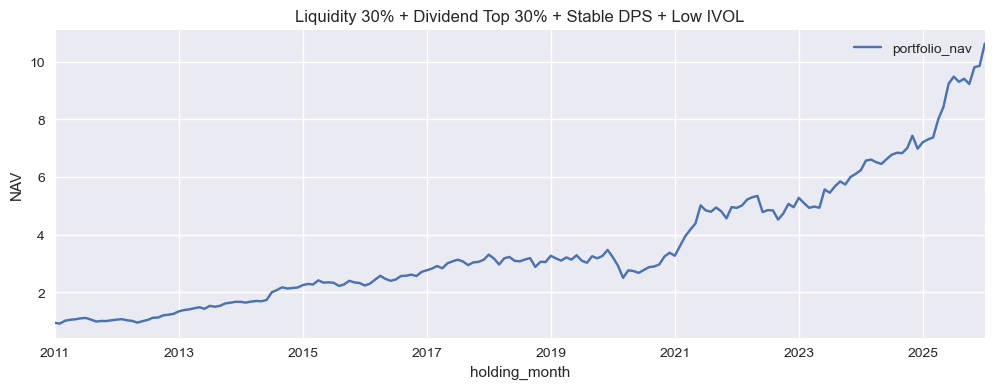

In [29]:
# 셀 6. 결과 파일을 저장하고 주요 결과를 출력합니다.

# 저장할 파일 경로를 한 번에 정의합니다.
output_paths = {
    "monthly_returns": BASE_DIR / f"{OUTPUT_PREFIX}_monthly_returns.csv",
    "nav": BASE_DIR / f"{OUTPUT_PREFIX}_nav.csv",
    "holdings": BASE_DIR / f"{OUTPUT_PREFIX}_holdings.csv",
    "selection_stats": BASE_DIR / f"{OUTPUT_PREFIX}_selection_stats.csv",
    "performance": BASE_DIR / f"{OUTPUT_PREFIX}_performance.csv",
}

# 각 결과 DataFrame을 CSV로 저장합니다.
for key, path in output_paths.items():
    outputs[key].to_csv(path, encoding="utf-8-sig")

# 가장 최근 리밸런싱 결과를 빠르게 확인하기 위한 정보입니다.
latest_holding_month = holdings_df.index.max()
latest_selection_date = selection_stats_df["selection_date"].max()
latest_names = holdings_df.loc[latest_holding_month].dropna().tolist()

# 핵심 성과, 최근 선정 통계, 최근 보유종목을 순서대로 보여줍니다.
display(performance_df.round(4))
display(selection_stats_df.tail())
display(holdings_df.tail())

# 텍스트 형태로도 최신 리밸런싱 결과를 출력합니다.
print(f"Latest selection date: {latest_selection_date.date().isoformat()}")
print(f"Latest holding month: {latest_holding_month.date().isoformat()}")
print("Latest holdings:")
print(", ".join(latest_names))
print()
print("Saved files")
for key, path in output_paths.items():
    print(f"- {key}: {path}")

# 전략 누적성과를 시각적으로 확인하기 위한 NAV 그래프입니다.
nav_df.plot(figsize=(12, 4), title="Liquidity 30% + Dividend Top 30% + Stable DPS + Low IVOL")
plt.ylabel("NAV")
plt.show()


## 셀 7. 운용가능 규모와 VaR 파라미터

`운용가능 규모`는 유동성 참여율과 진입/리밸런싱 일수를 바탕으로 계산하고, `투자위험등급`은 `97.5% VaR` 기준으로 산출합니다.


In [30]:
# 셀 7. 운용가능 규모와 VaR 계산에 사용할 파라미터와 함수입니다.

# 하루 거래대금 중 실제 집행 가능한 비율 가정입니다.
# 예: 0.10이면 하루 평균 거래대금의 10%까지만 참여한다고 봅니다.
MAX_DAILY_PARTICIPATION = 0.10

# 최초 포지션 구축에 허용할 거래일 수입니다.
BUILD_DAYS = 5

# 정기 리밸런싱 주문을 소화할 수 있다고 보는 거래일 수입니다.
REBALANCE_DAYS = 3

# VaR 계산 시 참고할 최대 과거 기간입니다.
VAR_LOOKBACK_YEARS = 3

# 월말 롤링 VaR를 계산할 때 필요한 최소 일간 관측치 수입니다.
MIN_VAR_OBS = 200

# 거래대금 파일의 원본 단위를 원화로 환산하는 배수입니다.
# 기본값 10,000은 원본 trading value 60.csv를 '만원' 단위로 보는 가정입니다.
# 필요하면 1(원), 1_000(천원), 10_000(만원) 중 맞는 값으로 조정하세요.
LIQUIDITY_VALUE_UNIT_MULTIPLIER = 10_000

# 운용가능 규모 / VaR 관련 CSV 파일명 접두어입니다.
ANALYTICS_PREFIX = OUTPUT_PREFIX


# 97.5% VaR 값을 투자위험등급으로 바꾸는 함수입니다.
def risk_grade_from_var(var_pct: float):
    if pd.isna(var_pct):
        return np.nan, 'N/A'
    if var_pct > 50:
        return 1, '매우 높은 위험'
    if var_pct > 30:
        return 2, '높은 위험'
    if var_pct > 20:
        return 3, '다소 높은 위험'
    if var_pct > 10:
        return 4, '보통 위험'
    if var_pct > 1:
        return 5, '낮은 위험'
    return 6, '매우 낮은 위험'


# 일간 수익률 시리즈에서 97.5% VaR를 연환산 % 기준으로 계산합니다.
def calc_var_97_5_pct(daily_ret: pd.Series) -> float:
    clean = daily_ret.dropna()
    if clean.empty:
        return np.nan
    return abs(clean.quantile(0.025)) * np.sqrt(250) * 100


# wide 형태의 holdings_df를 월별 종목 매핑 딕셔너리로 바꿉니다.
def make_holding_mapping_from_wide(holdings_wide: pd.DataFrame, available_columns: pd.Index):
    stock_cols = [col for col in holdings_wide.columns if col.startswith('stock_')]
    month_to_stocks = {}
    rows = []

    for holding_month, row in holdings_wide.iterrows():
        raw_stocks = [
            row[col]
            for col in stock_cols
            if pd.notna(row[col]) and str(row[col]).strip() != ''
        ]
        valid_stocks = [stock for stock in raw_stocks if stock in available_columns]
        missing_stocks = [stock for stock in raw_stocks if stock not in available_columns]
        holding_period = pd.Timestamp(holding_month).to_period('M')

        month_to_stocks[holding_period] = valid_stocks
        rows.append({
            'holding_month': pd.Timestamp(holding_month),
            'holding_period': str(holding_period),
            'n_raw_stocks': len(raw_stocks),
            'n_valid_stocks': len(valid_stocks),
            'n_missing_stocks': len(missing_stocks),
            'missing_stocks': ', '.join(map(str, missing_stocks)),
        })

    mapping_stats = pd.DataFrame(rows).set_index('holding_month').sort_index()
    return month_to_stocks, mapping_stats


# 월별 보유종목 변화를 기반으로 동일가중 one-way turnover를 계산합니다.
def calc_equal_weight_turnover(holdings_wide: pd.DataFrame) -> pd.DataFrame:
    stock_cols = [col for col in holdings_wide.columns if col.startswith('stock_')]
    prev_weights = None
    rows = []

    for holding_month, row in holdings_wide.iterrows():
        names = [
            row[col]
            for col in stock_cols
            if pd.notna(row[col]) and str(row[col]).strip() != ''
        ]
        if len(names) == 0:
            current_weights = pd.Series(dtype=float)
        else:
            current_weights = pd.Series(1 / len(names), index=pd.Index(names, dtype=object))

        if prev_weights is None:
            one_way_turnover = np.nan
        else:
            union_index = prev_weights.index.union(current_weights.index)
            prev_aligned = prev_weights.reindex(union_index, fill_value=0.0)
            curr_aligned = current_weights.reindex(union_index, fill_value=0.0)
            one_way_turnover = 0.5 * (curr_aligned - prev_aligned).abs().sum()

        rows.append({
            'holding_month': pd.Timestamp(holding_month),
            'n_holdings': len(names),
            'one_way_turnover': one_way_turnover,
        })
        prev_weights = current_weights

    return pd.DataFrame(rows).set_index('holding_month').sort_index()


## 셀 8. 일간 포트폴리오 수익률 생성


In [31]:
# 셀 8. 일간 가격을 정리하고 VaR 계산용 일간 포트폴리오 수익률을 만듭니다.

# 배당반영수정주가 원본을 일간 기준 숫자형 패널로 정리합니다.
prices_daily = adj_close_raw.apply(pd.to_numeric, errors='coerce').sort_index()

# 주말 행은 제거합니다.
weekday_mask = prices_daily.index.dayofweek < 5

# 데이터 제공 파일에 전체 종목 가격이 모두 그대로인 행이 있을 수 있어,
# 이런 날은 시장 비거래일로 보고 제거합니다.
market_change_mask = prices_daily.ne(prices_daily.shift(1)).any(axis=1)
market_change_mask.iloc[0] = True
prices_filtered = prices_daily.loc[weekday_mask & market_change_mask].copy()

# 개별 종목 일간 수익률을 계산합니다.
daily_stock_ret = prices_filtered.pct_change(fill_method=None)

# 월별 보유종목과 실제 가격 데이터 컬럼을 매핑합니다.
month_to_stocks, mapping_stats = make_holding_mapping_from_wide(holdings_df, daily_stock_ret.columns)

# 일간 포트폴리오 수익률과 유효 종목 수를 담을 빈 시리즈입니다.
portfolio_daily_ret = pd.Series(index=daily_stock_ret.index, dtype=float)
portfolio_n_names = pd.Series(index=daily_stock_ret.index, dtype=float)

# 각 holding month에 대해 같은 달의 모든 거래일에 동일한 동일가중 보유종목을 적용합니다.
for holding_period, stocks in month_to_stocks.items():
    period_dates = daily_stock_ret.index[daily_stock_ret.index.to_period('M') == holding_period]
    if len(period_dates) == 0 or len(stocks) == 0:
        continue

    sub = daily_stock_ret.loc[period_dates, stocks]
    portfolio_daily_ret.loc[period_dates] = sub.mean(axis=1, skipna=True)
    portfolio_n_names.loc[period_dates] = sub.notna().sum(axis=1)

# 최종 VaR 계산용 일간 수익률 패널입니다.
portfolio_daily = pd.DataFrame({
    'portfolio_daily_ret': portfolio_daily_ret,
    'n_available_names': portfolio_n_names,
}).dropna(subset=['portfolio_daily_ret'])
portfolio_daily['portfolio_nav'] = (1 + portfolio_daily['portfolio_daily_ret']).cumprod()

print('포트폴리오 일간 수익률 기간:', portfolio_daily.index.min(), '~', portfolio_daily.index.max())
print('일간 관측치 수           :', len(portfolio_daily))
print('일평균 유효 종목 수       :', round(portfolio_daily['n_available_names'].mean(), 2))
display(mapping_stats.tail())


포트폴리오 일간 수익률 기간: 2011-01-03 00:00:00 ~ 2026-01-30 00:00:00
일간 관측치 수           : 3935
일평균 유효 종목 수       : 10.0


,holding_period,n_raw_stocks,n_valid_stocks,n_missing_stocks,missing_stocks
holding_month,,,,,
2025-09-30,2025-09,10,10,0,
2025-10-31,2025-10,10,10,0,
2025-11-30,2025-11,10,10,0,
2025-12-31,2025-12,10,10,0,
2026-01-31,2026-01,10,10,0,


## 셀 9. 최신 기준 운용가능 규모 계산

In [32]:
# 셀 9. 최신 리밸런싱 기준 운용가능 규모를 계산합니다.

# 최신 holding month와 그에 대응하는 selection date를 찾습니다.
capacity_holding_month = holdings_df.index.max()
capacity_selection_date = selection_stats_df.loc[
    selection_stats_df['holding_month'] == capacity_holding_month,
    'selection_date'
].iloc[-1]
latest_holdings = holdings_df.loc[capacity_holding_month].dropna().tolist()

# 최신 선정 시점의 월말 60일 평균 거래대금을 가져옵니다.
latest_adv_raw = liquidity.loc[capacity_selection_date, latest_holdings].astype(float)

# 거래대금 파일 원본 단위를 원화 기준으로 환산합니다.
latest_adv_krw = latest_adv_raw * LIQUIDITY_VALUE_UNIT_MULTIPLIER

# 동일가중 전략이므로 종목당 목표 비중은 동일합니다.
target_weight = 1 / len(latest_holdings)

# 종목별 최초 포지션 구축 가능 규모를 계산합니다.
# AUM * 종목비중 <= ADV * 참여율 * 진입일수 조건을 뒤집은 값입니다.
capacity_by_stock = pd.DataFrame({
    'ticker': latest_holdings,
    'adv_60_raw': latest_adv_raw.values,
    'adv_60_krw': latest_adv_krw.values,
})
capacity_by_stock['target_weight'] = target_weight
capacity_by_stock['max_daily_participation'] = MAX_DAILY_PARTICIPATION
capacity_by_stock['build_days'] = BUILD_DAYS
capacity_by_stock['liquidity_unit_multiplier'] = LIQUIDITY_VALUE_UNIT_MULTIPLIER
capacity_by_stock['position_capacity_krw'] = (
    capacity_by_stock['adv_60_krw']
    * capacity_by_stock['max_daily_participation']
    * capacity_by_stock['build_days']
    / capacity_by_stock['target_weight']
)
capacity_by_stock['adv_60_억원'] = capacity_by_stock['adv_60_krw'] / 1e8
capacity_by_stock['position_capacity_억원'] = capacity_by_stock['position_capacity_krw'] / 1e8
capacity_by_stock = capacity_by_stock.sort_values('position_capacity_krw').reset_index(drop=True)

# 월별 보유종목 변화로부터 평균 one-way turnover를 계산합니다.
turnover_summary = calc_equal_weight_turnover(holdings_df)
avg_one_way_turnover = turnover_summary['one_way_turnover'].dropna().mean()
latest_one_way_turnover = turnover_summary.loc[capacity_holding_month, 'one_way_turnover']

# 포트폴리오 전체 바스켓 유동성 관점의 리밸런싱 capacity입니다.
entry_capacity_krw = capacity_by_stock['position_capacity_krw'].min()
rebalance_liquidity_budget_krw = latest_adv_krw.sum() * MAX_DAILY_PARTICIPATION * REBALANCE_DAYS
rebalance_capacity_krw = (
    rebalance_liquidity_budget_krw / avg_one_way_turnover
    if pd.notna(avg_one_way_turnover) and avg_one_way_turnover > 0
    else np.nan
)

# 둘 중 더 보수적인 값을 최종 운용가능 규모로 정의합니다.
capacity_candidates = [value for value in [entry_capacity_krw, rebalance_capacity_krw] if pd.notna(value)]
sustainable_capacity_krw = min(capacity_candidates) if capacity_candidates else np.nan

capacity_summary = pd.DataFrame([
    {
        'selection_date': capacity_selection_date,
        'holding_month': capacity_holding_month,
        'n_holdings': len(latest_holdings),
        'target_weight_per_name': target_weight,
        'max_daily_participation': MAX_DAILY_PARTICIPATION,
        'build_days': BUILD_DAYS,
        'rebalance_days': REBALANCE_DAYS,
        'liquidity_unit_multiplier': LIQUIDITY_VALUE_UNIT_MULTIPLIER,
        'basket_adv_60_raw': latest_adv_raw.sum(),
        'basket_adv_60_krw': latest_adv_krw.sum(),
        'basket_adv_60_억원': latest_adv_krw.sum() / 1e8,
        'avg_one_way_turnover': avg_one_way_turnover,
        'latest_one_way_turnover': latest_one_way_turnover,
        'entry_capacity_krw': entry_capacity_krw,
        'entry_capacity_억원': entry_capacity_krw / 1e8,
        'rebalance_capacity_krw': rebalance_capacity_krw,
        'rebalance_capacity_억원': rebalance_capacity_krw / 1e8 if pd.notna(rebalance_capacity_krw) else np.nan,
        'sustainable_capacity_krw': sustainable_capacity_krw,
        'sustainable_capacity_억원': sustainable_capacity_krw / 1e8 if pd.notna(sustainable_capacity_krw) else np.nan,
        'bottleneck_ticker': capacity_by_stock.loc[0, 'ticker'],
        'bottleneck_adv_60_억원': capacity_by_stock.loc[0, 'adv_60_억원'],
    }
])

print('최신 기준 운용가능 규모 요약')
display(capacity_summary)
print('종목별 진입 capacity (보수적 순 정렬)')
display(capacity_by_stock.head(10))


최신 기준 운용가능 규모 요약


,selection_date,holding_month,n_holdings,target_weight_per_name,max_daily_participation,build_days,rebalance_days,liquidity_unit_multiplier,basket_adv_60_raw,basket_adv_60_krw,...,avg_one_way_turnover,latest_one_way_turnover,entry_capacity_krw,entry_capacity_억원,rebalance_capacity_krw,rebalance_capacity_억원,sustainable_capacity_krw,sustainable_capacity_억원,bottleneck_ticker,bottleneck_adv_60_억원
0,2025-12-31,2026-01-31,10,0.1,0.1,5,3,10000,4443883.0,4.443883e+10,...,0.146111,0.1,5.894700e+09,58.947,9.124323e+10,912.432251,5.894700e+09,58.947,오리온홀딩스,11.7894


종목별 진입 capacity (보수적 순 정렬)


,ticker,adv_60_raw,adv_60_krw,target_weight,max_daily_participation,build_days,liquidity_unit_multiplier,position_capacity_krw,adv_60_억원,position_capacity_억원
0,오리온홀딩스,117894.0,1.178940e+09,0.1,0.1,5,10000,5.894700e+09,11.7894,58.9470
1,이노션,187328.0,1.873280e+09,0.1,0.1,5,10000,9.366400e+09,18.7328,93.6640
2,유진기업,198857.0,1.988570e+09,0.1,0.1,5,10000,9.942850e+09,19.8857,99.4285
3,한국캐피탈,226480.0,2.264800e+09,0.1,0.1,5,10000,1.132400e+10,22.6480,113.2400
4,KT&G,288210.0,2.882100e+09,0.1,0.1,5,10000,1.441050e+10,28.8210,144.1050
5,코리안리,296686.0,2.966860e+09,0.1,0.1,5,10000,1.483430e+10,29.6686,148.3430
6,제일기획,390154.0,3.901540e+09,0.1,0.1,5,10000,1.950770e+10,39.0154,195.0770
7,SK텔레콤,809783.0,8.097830e+09,0.1,0.1,5,10000,4.048915e+10,80.9783,404.8915
8,LG유플러스,916125.0,9.161250e+09,0.1,0.1,5,10000,4.580625e+10,91.6125,458.0625
9,기업은행,1012366.0,1.012366e+10,0.1,0.1,5,10000,5.061830e+10,101.2366,506.1830


## 셀 10. 최신 VaR(97.5%)와 투자위험등급

최신 평가일 기준 최근 최대 3년 일간 포트폴리오 수익률을 사용해 VaR를 계산하고, 이를 투자위험등급으로 매핑합니다.


In [33]:
# 셀 10. 최신 97.5% VaR와 투자위험등급을 계산합니다.

evaluation_date = portfolio_daily.index.max()
window_start_cutoff = evaluation_date - pd.DateOffset(years=VAR_LOOKBACK_YEARS)
latest_window = portfolio_daily.loc[
    portfolio_daily.index > window_start_cutoff,
    'portfolio_daily_ret'
].dropna()

latest_var_pct = calc_var_97_5_pct(latest_window)
latest_grade, latest_label = risk_grade_from_var(latest_var_pct)

latest_risk_summary = pd.DataFrame([
    {
        'evaluation_date': evaluation_date,
        'window_start': latest_window.index.min() if not latest_window.empty else pd.NaT,
        'window_end': latest_window.index.max() if not latest_window.empty else pd.NaT,
        'n_obs': len(latest_window),
        'var_97_5_pct': latest_var_pct,
        'risk_grade': latest_grade,
        'risk_label': latest_label,
    }
])

print('최신 97.5% VaR / 투자위험등급')
display(latest_risk_summary)


최신 97.5% VaR / 투자위험등급


,evaluation_date,window_start,window_end,n_obs,var_97_5_pct,risk_grade,risk_label
0,2026-01-30,2023-01-31,2026-01-30,784,23.035925,3,다소 높은 위험


## 셀 11. 월말 롤링 VaR 시계열과 파일 저장


월말 롤링 VaR / 위험등급 tail


,window_start,window_end,n_obs,var_97_5_pct,risk_grade,risk_label
date,,,,,,
2025-09-30,2022-10-03,2025-09-30,782,24.001527,3,다소 높은 위험
2025-10-31,2022-11-01,2025-10-31,784,23.604958,3,다소 높은 위험
2025-11-30,2022-12-01,2025-11-28,782,24.001527,3,다소 높은 위험
2025-12-31,2023-01-02,2025-12-31,783,23.611734,3,다소 높은 위험
2026-01-31,2023-02-01,2026-01-30,783,23.053476,3,다소 높은 위험


저장된 추가 분석 파일
- portfolio_daily: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_daily_returns_for_var.csv
- holding_mapping: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_holding_name_mapping_stats.csv
- turnover: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_turnover_for_capacity.csv
- capacity_by_stock: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_latest_capacity_by_stock.csv
- capacity_summary: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_latest_capacity_summary.csv
- latest_var_risk_grade: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_latest_var_risk_grade.csv
- rolling_var_risk_grade: /Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/고배당전략/liquidity30_divtop30_dpsstable_ivol15_ew_rolling_monthly_var_risk_grade.csv


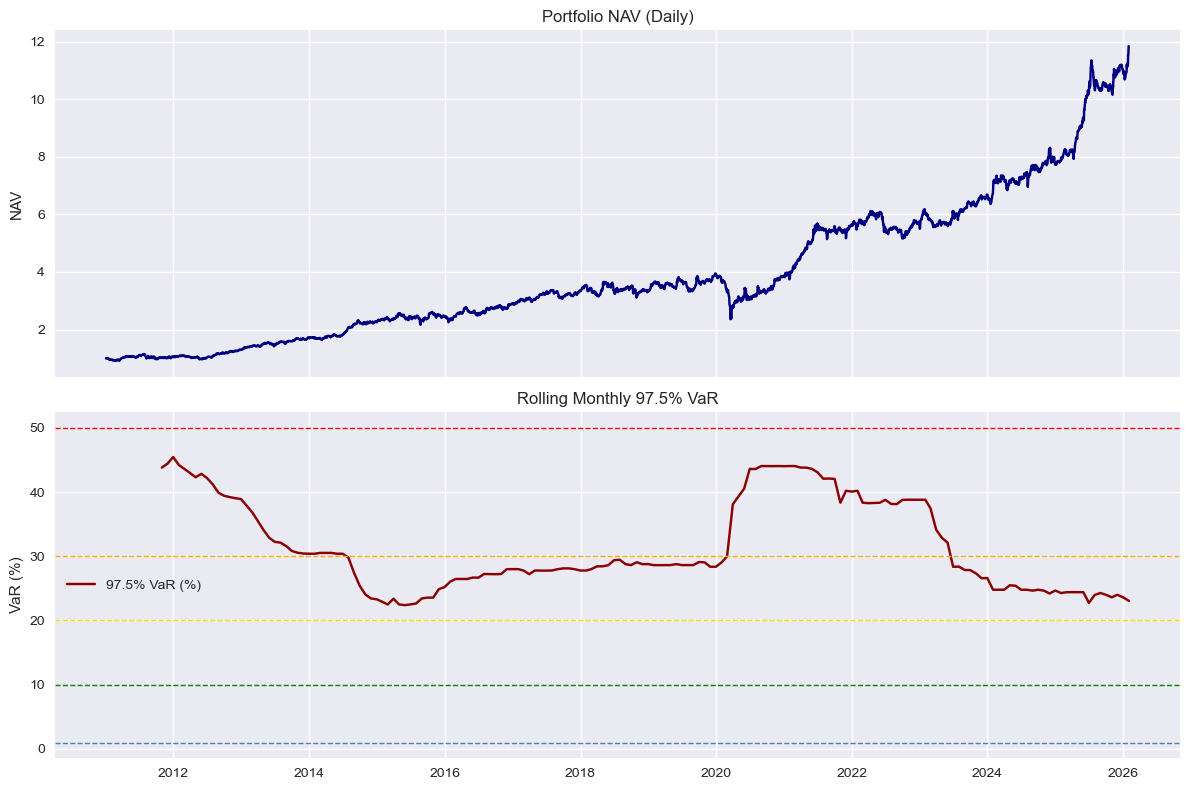

In [34]:
# 셀 11. 월말 롤링 VaR 시계열을 만들고 결과 파일을 저장합니다.

rolling_rows = []
month_end_index = portfolio_daily['portfolio_daily_ret'].resample('ME').last().index

for dt in month_end_index:
    window = portfolio_daily.loc[
        (portfolio_daily.index <= dt)
        & (portfolio_daily.index > dt - pd.DateOffset(years=VAR_LOOKBACK_YEARS)),
        'portfolio_daily_ret'
    ].dropna()
    if len(window) < MIN_VAR_OBS:
        continue

    var_pct = calc_var_97_5_pct(window)
    risk_grade, risk_label = risk_grade_from_var(var_pct)
    rolling_rows.append({
        'date': dt,
        'window_start': window.index.min(),
        'window_end': window.index.max(),
        'n_obs': len(window),
        'var_97_5_pct': var_pct,
        'risk_grade': risk_grade,
        'risk_label': risk_label,
    })

rolling_risk_summary = pd.DataFrame(rolling_rows).set_index('date').sort_index()

# 저장할 CSV 경로를 정의합니다.
risk_capacity_output_paths = {
    'portfolio_daily': BASE_DIR / f'{ANALYTICS_PREFIX}_daily_returns_for_var.csv',
    'holding_mapping': BASE_DIR / f'{ANALYTICS_PREFIX}_holding_name_mapping_stats.csv',
    'turnover': BASE_DIR / f'{ANALYTICS_PREFIX}_turnover_for_capacity.csv',
    'capacity_by_stock': BASE_DIR / f'{ANALYTICS_PREFIX}_latest_capacity_by_stock.csv',
    'capacity_summary': BASE_DIR / f'{ANALYTICS_PREFIX}_latest_capacity_summary.csv',
    'latest_var_risk_grade': BASE_DIR / f'{ANALYTICS_PREFIX}_latest_var_risk_grade.csv',
    'rolling_var_risk_grade': BASE_DIR / f'{ANALYTICS_PREFIX}_rolling_monthly_var_risk_grade.csv',
}

portfolio_daily.to_csv(risk_capacity_output_paths['portfolio_daily'], encoding='utf-8-sig')
mapping_stats.to_csv(risk_capacity_output_paths['holding_mapping'], encoding='utf-8-sig')
turnover_summary.to_csv(risk_capacity_output_paths['turnover'], encoding='utf-8-sig')
capacity_by_stock.to_csv(risk_capacity_output_paths['capacity_by_stock'], index=False, encoding='utf-8-sig')
capacity_summary.to_csv(risk_capacity_output_paths['capacity_summary'], index=False, encoding='utf-8-sig')
latest_risk_summary.to_csv(risk_capacity_output_paths['latest_var_risk_grade'], index=False, encoding='utf-8-sig')
rolling_risk_summary.to_csv(risk_capacity_output_paths['rolling_var_risk_grade'], encoding='utf-8-sig')

print('월말 롤링 VaR / 위험등급 tail')
display(rolling_risk_summary.tail())
print('저장된 추가 분석 파일')
for key, path in risk_capacity_output_paths.items():
    print(f'- {key}: {path}')

# NAV와 월말 롤링 VaR를 함께 시각화합니다.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(portfolio_daily.index, portfolio_daily['portfolio_nav'], color='navy')
axes[0].set_title('Portfolio NAV (Daily)')
axes[0].set_ylabel('NAV')
axes[0].grid(True)

axes[1].plot(rolling_risk_summary.index, rolling_risk_summary['var_97_5_pct'], color='darkred', label='97.5% VaR (%)')
axes[1].axhline(50, color='red', linestyle='--', linewidth=1)
axes[1].axhline(30, color='orange', linestyle='--', linewidth=1)
axes[1].axhline(20, color='gold', linestyle='--', linewidth=1)
axes[1].axhline(10, color='green', linestyle='--', linewidth=1)
axes[1].axhline(1, color='steelblue', linestyle='--', linewidth=1)
axes[1].set_title('Rolling Monthly 97.5% VaR')
axes[1].set_ylabel('VaR (%)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# E.O.C